<h2> Часть 1


В данной части практике будем рассматривать библиотеку [cupy](https://cupy.dev). **Цель** данной части практики рассмотреть простой способ вычисления с помощью gpu и сравнения перформанса с аналогичной реализацией на numpy.

Результатом данной практики должен быть оформленный отчет. В нём для каждого задания должны быть приведены: условие, реализация задания на двух фреймворках (numpy, cupy), таблица, в которой приведено сравнение времени работы этих двух реализаций и график, являющийся визуализацией вышеописанной таблицы.

In [61]:
import numpy as np
import cupy as cp
import time
import pandas as pd
import matplotlib.pyplot as plt
from contextlib import contextmanager
import math

# # Настройка графиков
# plt.rcParams['figure.figsize'] = (10, 6)
# plt.rcParams['font.size'] = 12

### Задание 1

Поэлементные операции с большими массивами.

На вход функции подаётся массив размерностью $N$. Необходимо реализовать вычисление выражения $y = \sqrt{x}+sin(x)⋅exp(−x)$ (используйте встроенные векторные функции, обычный for не даст вам ускорения). Для экспериментов ограничим значение, которое может принимать $N$ в задачах следующим интервалом [1, 10000000].

In [62]:
# NumPy
def numpy_compute(x):
    return np.sqrt(x) + np.sin(x) * np.exp(-x)

# CuPy
def cupy_compute(x_gpu):
    return cp.sqrt(x_gpu) + cp.sin(x_gpu) * cp.exp(-x_gpu)

In [63]:
num_sizes = 150
min_size = 10000
max_size = 10000000
sizes = np.linspace(min_size, max_size, num_sizes).astype(int)
sizes = sorted(set(sizes))

In [64]:
# sizes = [15000, 215000, 464000, 1000000, 2150000, 4640000, 10000000]
results = []

print("Запуск тестов...")
for n in sizes:
    # NumPy
    x_np = np.random.rand(n).astype(np.float64)
    start = time.perf_counter()
    y_np = numpy_compute(x_np)
    time_np = time.perf_counter() - start
    
    # CuPy
    x_cp = cp.asarray(x_np)
    start = time.perf_counter()
    y_cp = cupy_compute(x_cp)
    cp.cuda.Device(0).synchronize()
    time_cp_compute = time.perf_counter() - start
    

    results.append({
        'N': n,
        'NumPy': time_np,
        'CuPy_compute': time_cp_compute
    })
    
    print(f"N = {n:,} | NumPy: {time_np:.4f}s | CuPy: {time_cp_compute:.4f}s")

df = pd.DataFrame(results)

Запуск тестов...
N = 10,000 | NumPy: 0.0028s | CuPy: 0.0004s
N = 77,046 | NumPy: 0.0010s | CuPy: 0.0004s
N = 144,093 | NumPy: 0.0025s | CuPy: 0.0005s
N = 211,140 | NumPy: 0.0037s | CuPy: 0.0007s
N = 278,187 | NumPy: 0.0049s | CuPy: 0.0055s
N = 345,234 | NumPy: 0.0059s | CuPy: 0.0009s
N = 412,281 | NumPy: 0.0071s | CuPy: 0.0010s
N = 479,328 | NumPy: 0.0082s | CuPy: 0.0012s
N = 546,375 | NumPy: 0.0100s | CuPy: 0.0032s
N = 613,422 | NumPy: 0.0114s | CuPy: 0.0014s
N = 680,469 | NumPy: 0.0121s | CuPy: 0.0013s
N = 747,516 | NumPy: 0.0131s | CuPy: 0.0043s
N = 814,563 | NumPy: 0.0144s | CuPy: 0.0039s
N = 881,610 | NumPy: 0.0169s | CuPy: 0.0067s
N = 948,657 | NumPy: 0.0193s | CuPy: 0.0020s
N = 1,015,704 | NumPy: 0.0179s | CuPy: 0.0057s
N = 1,082,751 | NumPy: 0.0210s | CuPy: 0.0022s
N = 1,149,798 | NumPy: 0.0207s | CuPy: 0.0074s
N = 1,216,845 | NumPy: 0.0210s | CuPy: 0.0049s
N = 1,283,892 | NumPy: 0.0232s | CuPy: 0.0030s
N = 1,350,939 | NumPy: 0.0249s | CuPy: 0.0028s
N = 1,417,986 | NumPy: 0.025

In [65]:
# Вывод таблицой таблица
simple_table = df[['N', 'NumPy', 'CuPy_compute']].copy()
simple_table.columns = ['N count', 'np', 'cp']
print(simple_table.to_string(index=False, float_format='%.9f'))

 N count          np          cp
   10000 0.002767000 0.000391700
   77046 0.001045800 0.000433400
  144093 0.002501000 0.000483500
  211140 0.003720600 0.000670900
  278187 0.004913900 0.005486200
  345234 0.005935900 0.000930600
  412281 0.007063700 0.001048500
  479328 0.008234800 0.001173900
  546375 0.009965700 0.003203400
  613422 0.011424900 0.001423400
  680469 0.012123900 0.001304700
  747516 0.013119100 0.004325100
  814563 0.014413200 0.003886000
  881610 0.016904100 0.006671300
  948657 0.019284900 0.001964200
 1015704 0.017910600 0.005669400
 1082751 0.020994000 0.002199200
 1149798 0.020714800 0.007367800
 1216845 0.020964600 0.004925000
 1283892 0.023178800 0.002981900
 1350939 0.024930500 0.002779800
 1417986 0.025616300 0.004845100
 1485033 0.027034400 0.002873500
 1552080 0.027443800 0.003073800
 1619127 0.028323700 0.006555700
 1686174 0.029947500 0.004605700
 1753221 0.030483700 0.008982500
 1820268 0.032675900 0.010735000
 1887315 0.032447500 0.003776600
 1954362 0

50 - 100 значений

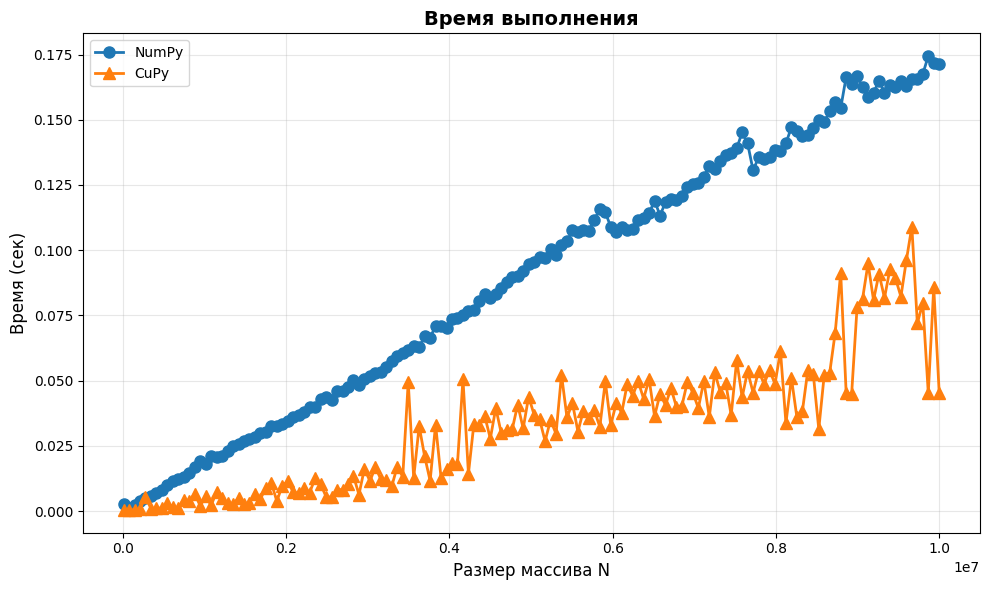

In [66]:
plt.figure(figsize=(10, 6))
plt.plot(df['N'], df['NumPy'], 'o-', label='NumPy', linewidth=2, markersize=8)
plt.plot(df['N'], df['CuPy_compute'], '^-', label='CuPy', linewidth=2, markersize=8)

plt.xlabel('Размер массива N', fontsize=12)
plt.ylabel('Время (сек)', fontsize=12)
plt.title('Время выполнения', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Задание 2

Расчет статистик.

На вход функции подаётся квадртаная матрицы $A$ размерностью $N \times N$. Необходимо реализовать функцию рассчета статистик (среднее значение, медиана, мода, дисперсия, среднеквадартаичное отклонение, первый и третий квартиль) для каждой колонки матрицы. Для экспериментов ограничим значение, которое может принимать $N$ в задачах следующим интервалом [1, 100000].

In [67]:
%matplotlib inline

# NumPy 
def numpy_statistics(A):
    """
    Расчет статистик для каждой колонки матрицы (NumPy)
    """
    n_cols = A.shape[1]
    stats_dict = {
        'mean': np.mean(A, axis=0),
        'median': np.median(A, axis=0),
        'variance': np.var(A, axis=0),
        'std': np.std(A, axis=0),
        'q1': np.percentile(A, 25, axis=0),
        'q3': np.percentile(A, 75, axis=0)
    }
    mode_result = stats.mode(A, axis=0, keepdims=True)
    stats_dict['mode'] = mode_result.mode[0]
    
    return stats_dict


# CuPy 
def cupy_statistics(A_gpu):
    """
    Расчет статистик для каждой колонки матрицы (CuPy)
    """
    stats_dict = {
        'mean': cp.mean(A_gpu, axis=0),
        'median': cp.median(A_gpu, axis=0),
        'variance': cp.var(A_gpu, axis=0),
        'std': cp.std(A_gpu, axis=0),
        'q1': cp.percentile(A_gpu, 25, axis=0),
        'q3': cp.percentile(A_gpu, 75, axis=0)
    }
    # Мода - в CuPy нет встроенной функции, используем приближение через mean
    stats_dict['mode'] = cp.mean(A_gpu, axis=0)  # упрощённо
    
    return stats_dict

In [68]:
num_sizes = 100
min_size = 100
max_size = 10000
sizes = np.linspace(min_size, max_size, num_sizes).astype(int)
sizes = sorted(set(sizes))

In [69]:
from scipy import stats
# Размеры матриц N×N
# sizes = [100, 500, 1000, 5000, 10000]
results = []

print("Запуск тестов...")
print("=" * 70)

for n in sizes:
    print(f"\nN = {n:,} (матрица {n}×{n})")
    
    # NumPy
    A_np = np.random.rand(n, n).astype(np.float64)
    start = time.perf_counter()
    stats_np = numpy_statistics(A_np)
    time_np = time.perf_counter() - start
    print(f"  NumPy: {time_np:.4f} сек")
    
    # CuPy
    A_cp = cp.asarray(A_np)
    start = time.perf_counter()
    stats_cp = cupy_statistics(A_cp)
    cp.cuda.Device(0).synchronize()
    time_cp_compute = time.perf_counter() - start
    print(f"  CuPy: {time_cp_compute:.4f} сек")
    
    
    results.append({
        'N': n,
        'NumPy': time_np,
        'CuPy_compute': time_cp_compute
    })

df = pd.DataFrame(results)


Запуск тестов...

N = 100 (матрица 100×100)
  NumPy: 0.0031 сек
  CuPy: 0.0014 сек

N = 200 (матрица 200×200)
  NumPy: 0.0060 сек
  CuPy: 0.0013 сек

N = 300 (матрица 300×300)
  NumPy: 0.0091 сек
  CuPy: 0.0012 сек

N = 400 (матрица 400×400)
  NumPy: 0.0189 сек
  CuPy: 0.0153 сек

N = 500 (матрица 500×500)
  NumPy: 0.0222 сек
  CuPy: 0.0023 сек

N = 600 (матрица 600×600)
  NumPy: 0.0303 сек
  CuPy: 0.0030 сек

N = 700 (матрица 700×700)
  NumPy: 0.0394 сек
  CuPy: 0.0035 сек

N = 800 (матрица 800×800)
  NumPy: 0.0557 сек
  CuPy: 0.0066 сек

N = 900 (матрица 900×900)
  NumPy: 0.0609 сек
  CuPy: 0.0082 сек

N = 1,000 (матрица 1000×1000)
  NumPy: 0.0736 сек
  CuPy: 0.0078 сек

N = 1,100 (матрица 1100×1100)
  NumPy: 0.0879 сек
  CuPy: 0.0139 сек

N = 1,200 (матрица 1200×1200)
  NumPy: 0.1068 сек
  CuPy: 0.0142 сек

N = 1,300 (матрица 1300×1300)
  NumPy: 0.1208 сек
  CuPy: 0.0189 сек

N = 1,400 (матрица 1400×1400)
  NumPy: 0.1335 сек
  CuPy: 0.0206 сек

N = 1,500 (матрица 1500×1500)
  NumPy:

KeyboardInterrupt: 

50 -100 значений макс 10000

In [ ]:
# Простая таблица
simple_table = df[['N', 'NumPy', 'CuPy_compute']].copy()
simple_table.columns = ['N count', 'np', 'cp']
print(simple_table.to_string(index=False, float_format='%.9f'))

 N count          np          cp
     100 0.003187500 0.001246300
    1200 0.103927500 0.028762500
    2300 0.413904500 0.108746700
    3400 1.031487600 0.171348300
    4500 1.837430200 0.291418100
    5600 3.040494700 0.391292500
    6700 3.955566400 0.482670500
    7800 5.534333300 4.890183600
    8900 7.115916600 6.846844100
   10000 9.459824400 9.092579900


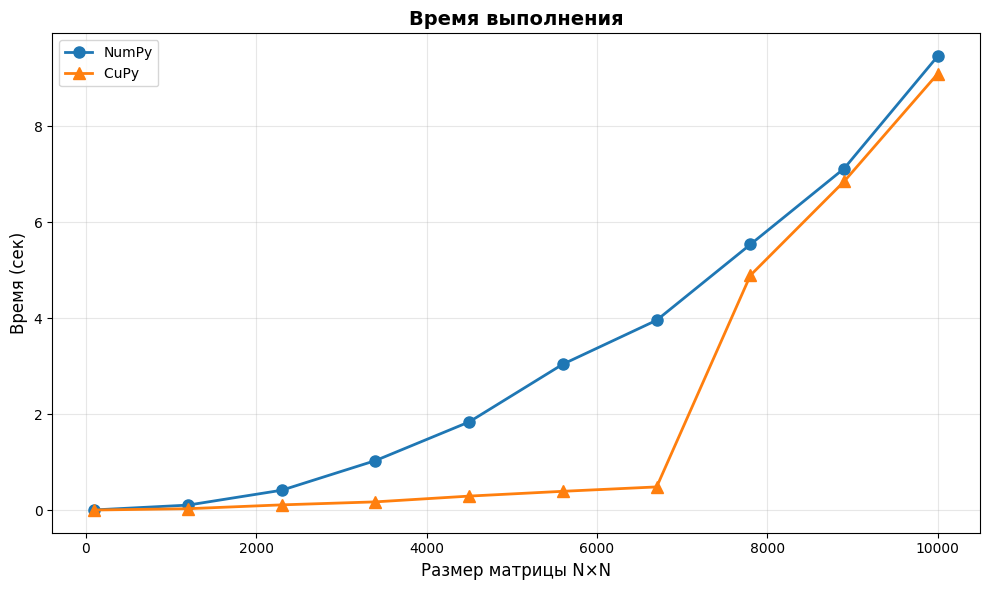

In [50]:
plt.figure(figsize=(10, 6))
plt.plot(df['N'], df['NumPy'], 'o-', label='NumPy', linewidth=2, markersize=8)
plt.plot(df['N'], df['CuPy_compute'], '^-', label='CuPy ', linewidth=2, markersize=8)

plt.xlabel('Размер матрицы N×N', fontsize=12)
plt.ylabel('Время (сек)', fontsize=12)
plt.title('Время выполнения', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Задание 3

Матричное умножение.

На вход функции подаётся две квадртаная матрицы $A$ и $B$ размерностью $N \times N$. Необходимо реализовать вычисление их произведения $C = A \cdot B$. Для экспериментов ограничим значение, которое может принимать $N$ в задачах следующим интервалом [1, 4096].

In [51]:
%matplotlib inline

# NumPy 
def numpy_matmul(A, B):
    """
    Матричное умножение C = A · B (NumPy)
    """
    return np.dot(A, B)

# CuPy 
def cupy_matmul(A_gpu, B_gpu):
    """
    Матричное умножение C = A · B (CuPy)
    """
    return cp.dot(A_gpu, B_gpu)

In [ ]:
num_sizes = 100
min_size = 10
max_size = 4096
sizes = np.linspace(min_size, max_size, num_sizes).astype(int)
sizes = sorted(set(sizes))

In [53]:
# Размеры матриц N×N
# sizes = [256, 512, 1024, 2048, 3072, 4096]
results = []

print("Запуск тестов...")
print("=" * 70)

for n in sizes:
    print(f"\nN = {n:,} (матрица {n}×{n})")
    
    # NumPy
    A_np = np.random.rand(n, n).astype(np.float64)
    B_np = np.random.rand(n, n).astype(np.float64)
    start = time.perf_counter()
    C_np = numpy_matmul(A_np, B_np)
    time_np = time.perf_counter() - start
    print(f"  NumPy: {time_np:.4f} сек")
    
    # CuPy
    A_cp = cp.asarray(A_np)
    B_cp = cp.asarray(B_np)
    start = time.perf_counter()
    C_cp = cupy_matmul(A_cp, B_cp)
    cp.cuda.Device(0).synchronize()
    time_cp_compute = time.perf_counter() - start
    print(f"  CuPy: {time_cp_compute:.4f} сек")
    
    results.append({
        'N': n,
        'NumPy': time_np,
        'CuPy_compute': time_cp_compute
    })

df = pd.DataFrame(results)

Запуск тестов...

N = 10 (матрица 10×10)
  NumPy: 0.0000 сек
  CuPy: 0.3313 сек

N = 464 (матрица 464×464)
  NumPy: 0.0069 сек
  CuPy: 0.0104 сек

N = 918 (матрица 918×918)
  NumPy: 0.0100 сек
  CuPy: 0.0143 сек

N = 1,372 (матрица 1372×1372)
  NumPy: 0.0227 сек
  CuPy: 0.0377 сек

N = 1,826 (матрица 1826×1826)
  NumPy: 0.0481 сек
  CuPy: 0.1445 сек

N = 2,280 (матрица 2280×2280)
  NumPy: 0.0904 сек
  CuPy: 0.1675 сек

N = 2,734 (матрица 2734×2734)
  NumPy: 0.1553 сек
  CuPy: 0.2876 сек

N = 3,188 (матрица 3188×3188)
  NumPy: 0.2404 сек
  CuPy: 0.8497 сек

N = 3,642 (матрица 3642×3642)
  NumPy: 0.3549 сек
  CuPy: 1.0704 сек

N = 4,096 (матрица 4096×4096)
  NumPy: 0.4939 сек
  CuPy: 0.9074 сек


In [54]:
# Простая таблица
simple_table = df[['N', 'NumPy', 'CuPy_compute']].copy()
simple_table.columns = ['N count', 'np', 'cp']
print(simple_table.to_string(index=False, float_format='%.9f'))

 N count          np          cp
      10 0.000013200 0.331332000
     464 0.006886300 0.010378500
     918 0.009968100 0.014264900
    1372 0.022740200 0.037743600
    1826 0.048113900 0.144499000
    2280 0.090395800 0.167496600
    2734 0.155329800 0.287563800
    3188 0.240376800 0.849714900
    3642 0.354856200 1.070391100
    4096 0.493885400 0.907446200


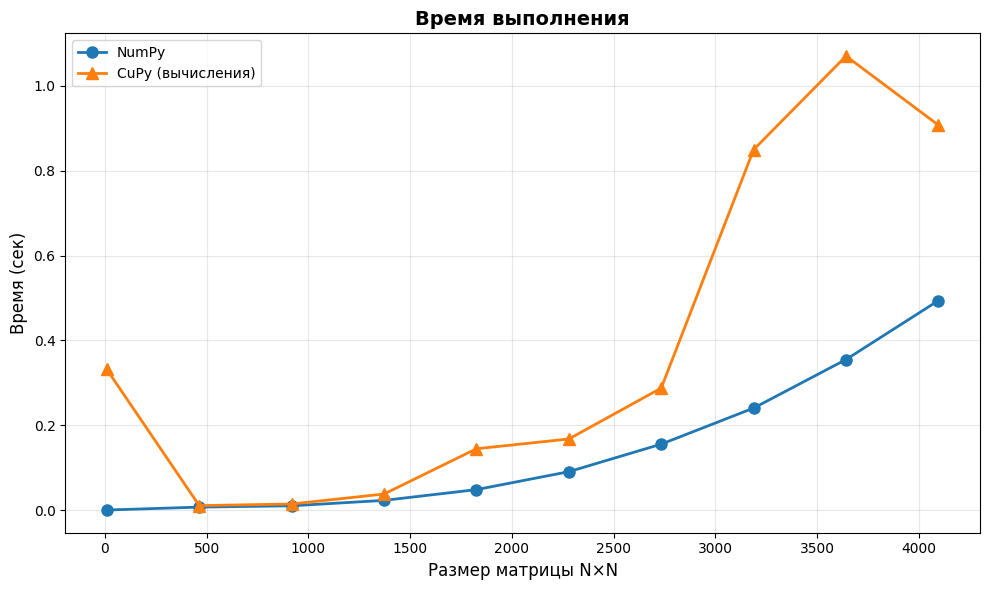

In [55]:
plt.figure(figsize=(10, 6))
plt.plot(df['N'], df['NumPy'], 'o-', label='NumPy', linewidth=2, markersize=8)
plt.plot(df['N'], df['CuPy_compute'], '^-', label='CuPy (вычисления)', linewidth=2, markersize=8)

plt.xlabel('Размер матрицы N×N', fontsize=12)
plt.ylabel('Время (сек)', fontsize=12)
plt.title('Время выполнения', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Задание 4

Ряд Маклорена.

На вход подается массив размерностью $N$ со значениями [-10, 10] и число $M$ - количество многочленов для апрокимации. Необходимо реализовать функцию, которая вычисляет разложение функции $sin(x)$ в ряд Маклорена для заданного массива и количество многочленов для апрокимации. Для экспериментов ограничим значение, которое может принимать $N$ в задачах следующим интервалом [1, 10000000], а $M$ - одним, любым значением, но не меньше 5.

In [56]:
%matplotlib inline

# NumPy 
def numpy_maclaurin_sin(x, M):
    """
    Вычисление sin(x) через ряд Маклорена (NumPy)
    sin(x) = Σ((-1)^k * x^(2k+1)) / (2k+1)! для k=0..M-1
    """
    result = np.zeros_like(x)
    for k in range(M):
        term = ((-1)**k) * (x**(2*k + 1)) / math.factorial(2*k + 1)
        result += term
    return result

# CuPy

def cupy_maclaurin_sin(x_gpu, M):
    """
    Вычисление sin(x) через ряд Маклорена (CuPy)
    """
    result = cp.zeros_like(x_gpu)
    for k in range(M):
        term = ((-1)**k) * (x_gpu**(2*k + 1)) / math.factorial(2*k + 1)
        result += term
    return result

In [57]:
num_sizes = 100
min_size = 1000
max_size = 10000000
sizes = np.linspace(min_size, max_size, num_sizes).astype(int)
sizes = sorted(set(sizes))

In [58]:
# Параметры
M = 10  # количество членов ряда (≥ 5)
# sizes = [100000, 500000, 1000000, 5000000, 10000000]
results = []

print(f"Запуск тестов (M = {M} членов ряда)...")
print("=" * 70)

for n in sizes:
    print(f"\nN = {n:,}")
    
    # Генерация данных в диапазоне [-10, 10]
    x_np = np.random.uniform(-10, 10, n).astype(np.float64)
    
    # NumPy
    start = time.perf_counter()
    y_np = numpy_maclaurin_sin(x_np, M)
    time_np = time.perf_counter() - start
    print(f"  NumPy: {time_np:.4f} сек")
    
    # CuPy
    x_cp = cp.asarray(x_np)
    start = time.perf_counter()
    y_cp = cupy_maclaurin_sin(x_cp, M)
    cp.cuda.Device(0).synchronize()
    time_cp_compute = time.perf_counter() - start
    print(f"  CuPy: {time_cp_compute:.4f} сек")
    
    
    results.append({
        'N': n,
        'NumPy': time_np,
        'CuPy_compute': time_cp_compute
    })

df = pd.DataFrame(results)

Запуск тестов (M = 10 членов ряда)...

N = 1,000
  NumPy: 0.0034 сек
  CuPy: 0.0506 сек

N = 102,000
  NumPy: 0.0148 сек
  CuPy: 0.0014 сек

N = 203,000
  NumPy: 0.0373 сек
  CuPy: 0.0046 сек

N = 304,000
  NumPy: 0.0568 сек
  CuPy: 0.0076 сек

N = 405,000
  NumPy: 0.0755 сек
  CuPy: 0.0093 сек

N = 506,000
  NumPy: 0.0950 сек
  CuPy: 0.0084 сек

N = 607,000
  NumPy: 0.1149 сек
  CuPy: 0.0158 сек

N = 708,000
  NumPy: 0.1303 сек
  CuPy: 0.0160 сек

N = 809,000
  NumPy: 0.1510 сек
  CuPy: 0.0167 сек

N = 910,000
  NumPy: 0.1684 сек
  CuPy: 0.0245 сек

N = 1,011,000
  NumPy: 0.1878 сек
  CuPy: 0.0212 сек

N = 1,112,000
  NumPy: 0.2069 сек
  CuPy: 0.0262 сек

N = 1,213,000
  NumPy: 0.2232 сек
  CuPy: 0.0559 сек

N = 1,314,000
  NumPy: 0.2434 сек
  CuPy: 0.0657 сек

N = 1,415,000
  NumPy: 0.2627 сек
  CuPy: 0.0498 сек

N = 1,516,000
  NumPy: 0.2818 сек
  CuPy: 0.0562 сек

N = 1,617,000
  NumPy: 0.2994 сек
  CuPy: 0.0640 сек

N = 1,718,000
  NumPy: 0.3160 сек
  CuPy: 0.0759 сек

N = 1,819,0

In [59]:
# Вывод таблица
simple_table = df[['N', 'NumPy', 'CuPy_compute']].copy()
simple_table.columns = ['N count', 'np', 'cp']
print(simple_table.to_string(index=False, float_format='%.9f'))

 N count          np          cp
    1000 0.003442600 0.050571500
  102000 0.014820400 0.001397200
  203000 0.037274000 0.004609300
  304000 0.056766400 0.007603800
  405000 0.075518600 0.009278000
  506000 0.095030300 0.008416300
  607000 0.114895700 0.015784500
  708000 0.130325400 0.015952700
  809000 0.151011500 0.016721300
  910000 0.168381800 0.024490200
 1011000 0.187815200 0.021174200
 1112000 0.206919000 0.026219900
 1213000 0.223160400 0.055858200
 1314000 0.243406900 0.065680300
 1415000 0.262684200 0.049825800
 1516000 0.281843700 0.056228200
 1617000 0.299398600 0.063954000
 1718000 0.316022800 0.075897800
 1819000 0.333626700 0.080945300
 1920000 0.356189300 0.083588600
 2021000 0.374520700 0.059367500
 2122000 0.390408100 0.075943800
 2223000 0.409400600 0.072579000
 2324000 0.433744400 0.064319300
 2425000 0.448141600 0.065247100
 2526000 0.465137300 0.076185200
 2627000 0.483758300 0.076199700
 2728000 0.502613200 0.075290100
 2829000 0.520931400 0.075630400
 2930000 0

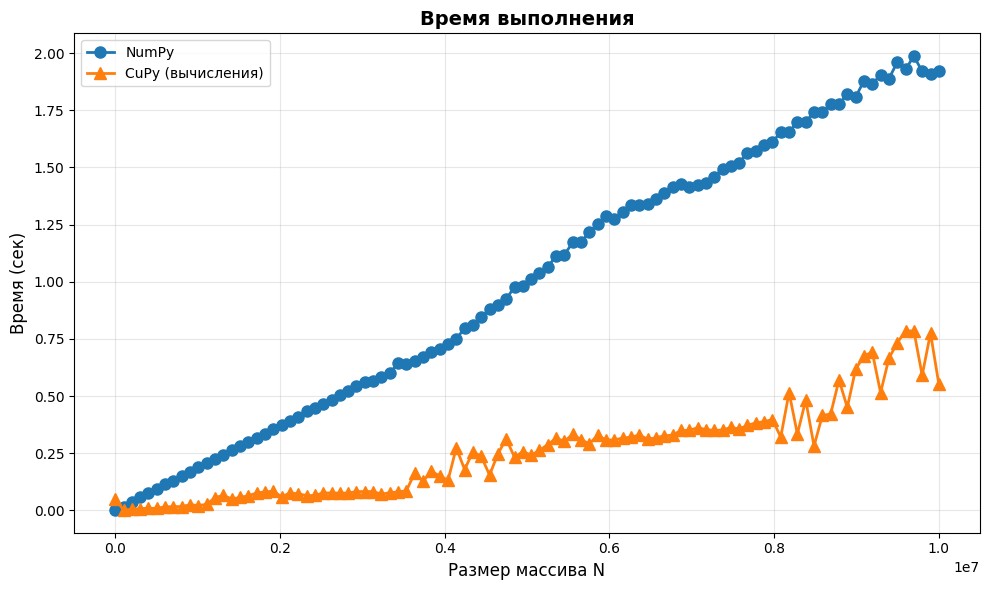

In [60]:
plt.figure(figsize=(10, 6))
plt.plot(df['N'], df['NumPy'], 'o-', label='NumPy', linewidth=2, markersize=8)
plt.plot(df['N'], df['CuPy_compute'], '^-', label='CuPy (вычисления)', linewidth=2, markersize=8)

plt.xlabel('Размер массива N', fontsize=12)
plt.ylabel('Время (сек)', fontsize=12)
plt.title('Время выполнения', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

50 - 100 значений